In [1]:
# Notebook display options, change as your preference/system
%matplotlib inline
%config InlineBackend.print_figure_kwargs={'facecolor' : "w",'bbox_inches':None}

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 120

In [2]:
# Notebook display options, change as your preference/syste

import sys
sys.path.insert(0,'..')
sys.path.insert(0,'../..')

from matplotlib import pyplot as plt 
import numpy as np 

from scipy.constants import micro, nano, milli

import pyMOE as moe 
from pyMOE.generate import *  
from pyMOE.propagate import * 
from pyMOE.metrics import * 
from pyMOE.optimizer import * 
from pyMOE.ensemble import * 

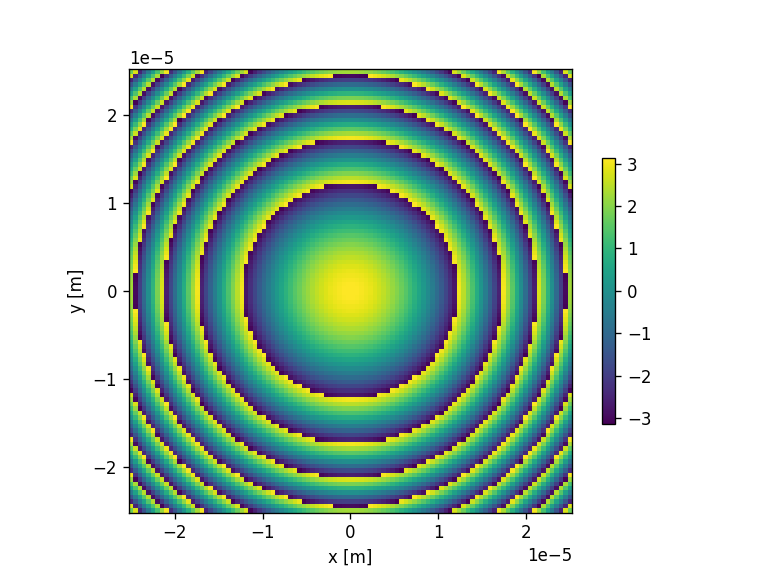

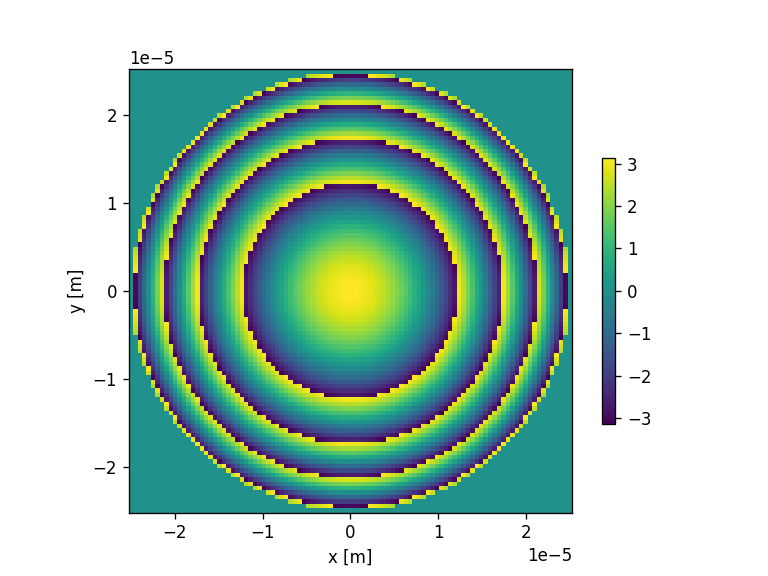

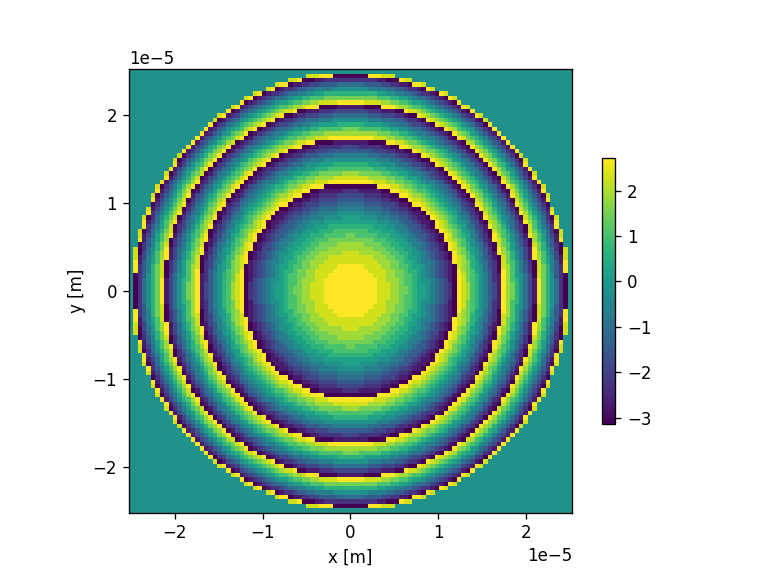

In [3]:
# First just for initialization purpose we will initalize a Fresnel lens 

#number of pixels 
x_pixel = 100
y_pixel = 100

#size of the rectangular mask 
aperture_width  = 50e-6 #m
aperture_height = 50e-6

pixsize = 1e-6 #m

wavelength = 500e-9 #m
focal_length = 150e-6

zmin = wavelength
zmax = 1.2* focal_length
nzs = 500

radius = aperture_width/2 

# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture with Fresnel mask 
mask1 = moe.generate.fresnel_phase(aperture1, focal_length, wavelength )

moe.plotting.plot_aperture(mask1)


##############
###Fresnel mask with a truncated circular aperture 

# Create empty mask
aperture2 = moe.generate.create_empty_aperture_from_aperture(aperture1)

# and truncate around radius
mask2 = moe.generate.fresnel_phase(aperture2, focal_length, wavelength, radius=radius)
moe.plotting.plot_aperture(mask2)

# Discretize mask in number of levels
# Select exact position of contours  in phase
phase_vals = np.linspace(-np.pi, np.pi, 16)

mask2.discretize(np.array( phase_vals)[:] ) 
moe.plotting.plot_aperture(mask2)

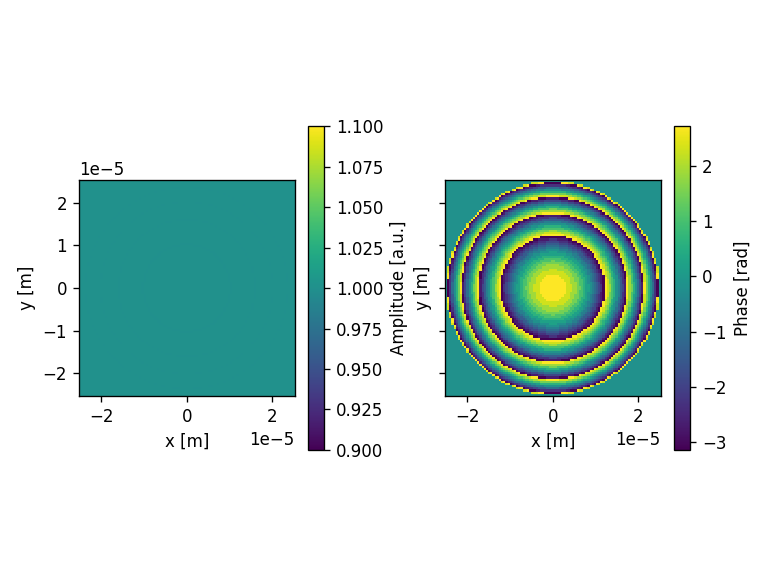

In [4]:
# Generate a uniform field
field = moe.field.create_empty_field_from_aperture(mask2)

field = moe.field.generate_uniform_field(field, E0=1)

# Modulates the field 
field = moe.field.modulate_field(field, amplitude_mask=None, phase_mask=mask2 )

# Plots the field (amplitude and phase)
moe.plotting.plot_field(field)

plt.tight_layout()
plt.show()


In [5]:
#Initial guess matrix

x_pixel, y_pixel = 100, 100


x0 = np.random.rand(x_pixel, y_pixel) 
x0_flatten = x0.flatten()


xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi)
 

In [6]:
#Define Screen 

# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

focal_length = 0.02

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.array([focal_length])


screen = moe.field.Screen(x,y,z)

#### Brief propagation method comparison 
The optimization will make use of the field propagated compared towards a target. In this respect accurate propagation is key. To investigate this aspect and investigate Bluestein, ASM and SASM propagation reliability at large distances and its connection with padding, below we look at some propagation examples.

Elapsed: 0:00:01.237568


C:\Users\jcunha377\AppData\Roaming\Python\Python311\site-packages\jax\_src\numpy\lax_numpy.py:148: UserWarning: Explicitly requested dtype complex128 requested in asarray is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return asarray(x, dtype=self.dtype)


Elapsed: 0:00:12.666906
Elapsed: 0:00:01.804582


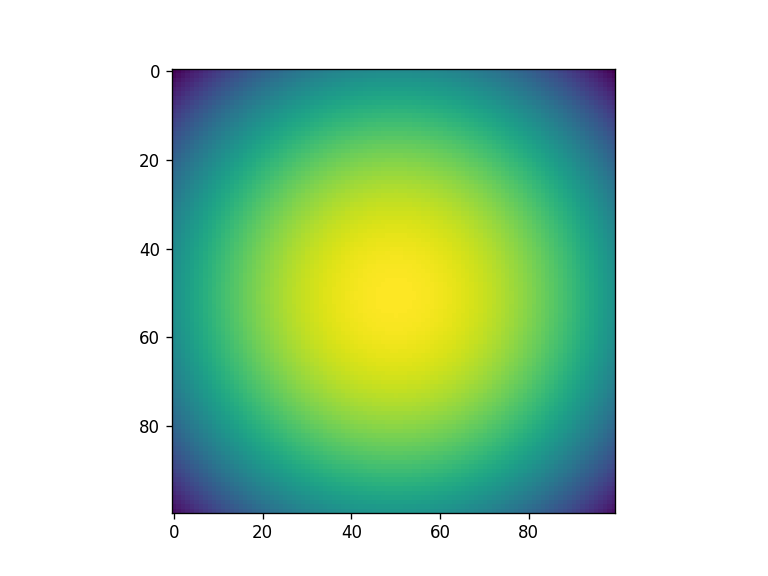

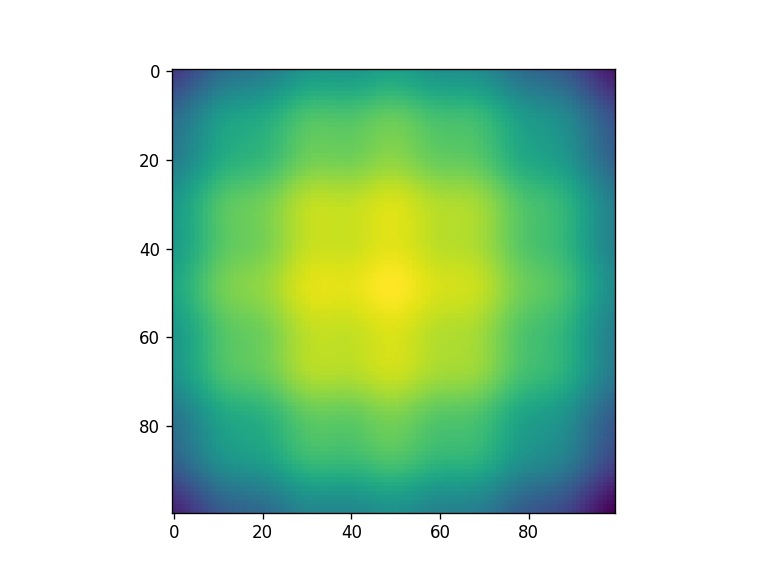

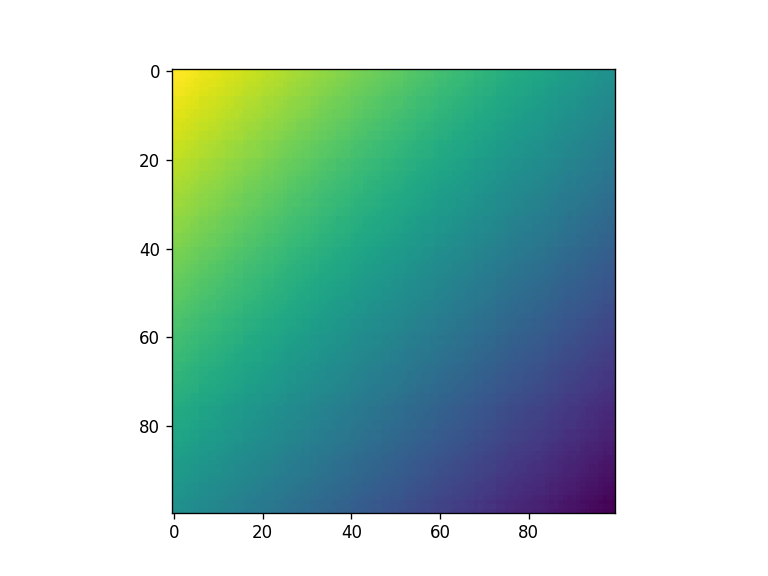

In [7]:
##check initial guess propagation with bluestein propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="bluestein"))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", pad_factor=2000))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", pad_factor=20))

fig = plt.figure() 
plt.imshow(np.abs(prop))

Elapsed: 0:00:00.015431
Elapsed: 0:00:22.201556


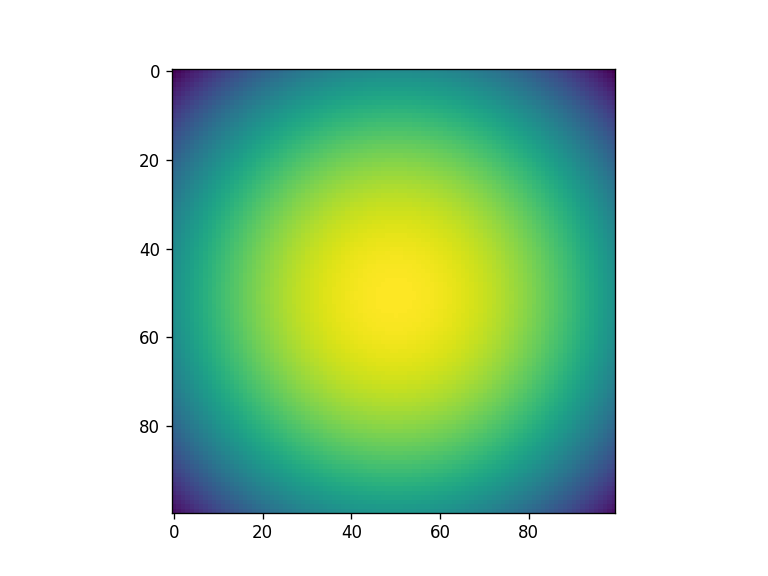

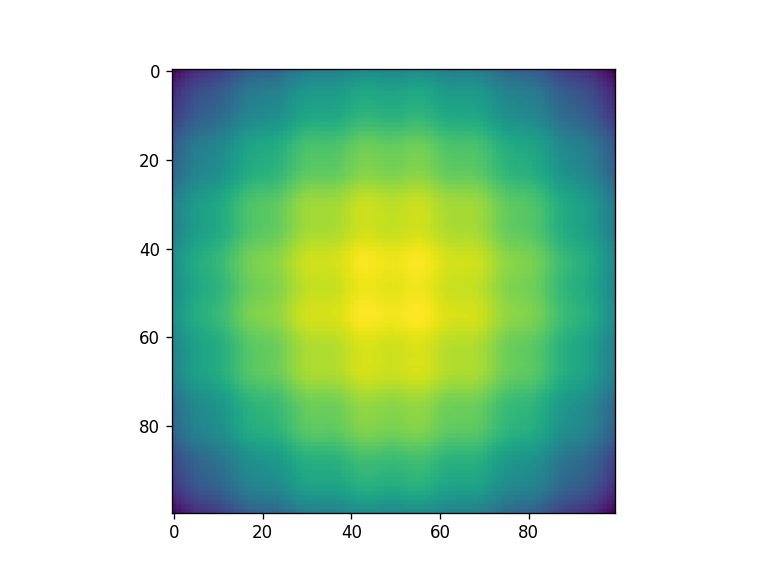

In [8]:
# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

focal_length = 0.02

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.array([focal_length])


screen = moe.field.Screen(x,y,z)


##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="bluestein"))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", pad_factor=3000))

fig = plt.figure() 
plt.imshow(np.abs(prop))

Elapsed: 0:00:00.027878
Elapsed: 0:00:37.138999


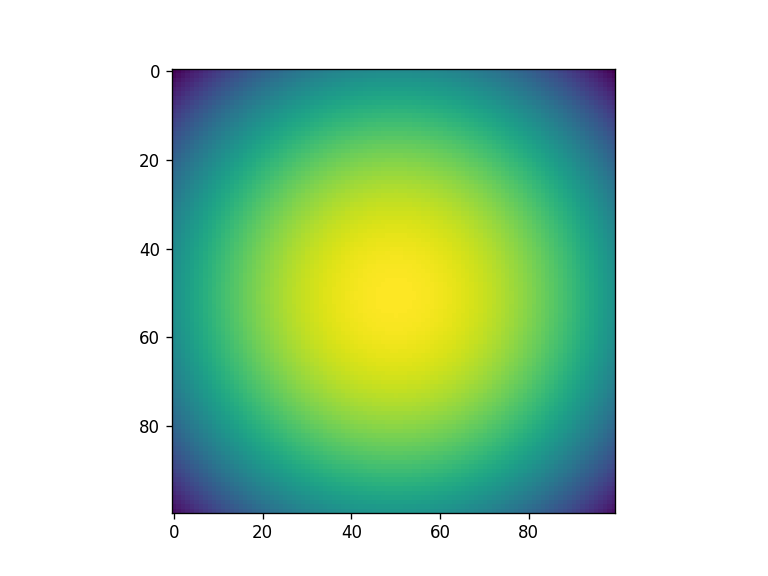

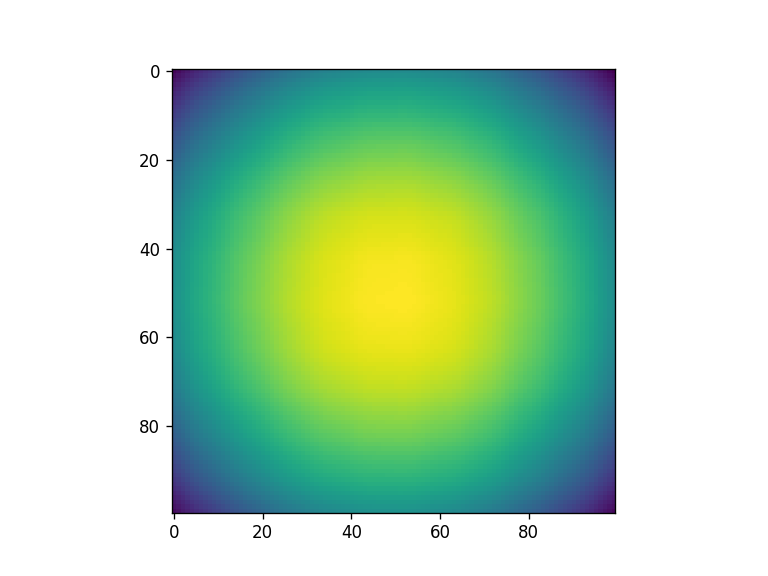

In [9]:
# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

focal_length = 0.02

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.array([focal_length])


screen = moe.field.Screen(x,y,z)


##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="bluestein"))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", pad_factor=4000))

fig = plt.figure() 
plt.imshow(np.abs(prop))


Elapsed: 0:00:00.023895
Elapsed: 0:00:40.945796
Elapsed: 0:00:00.048288


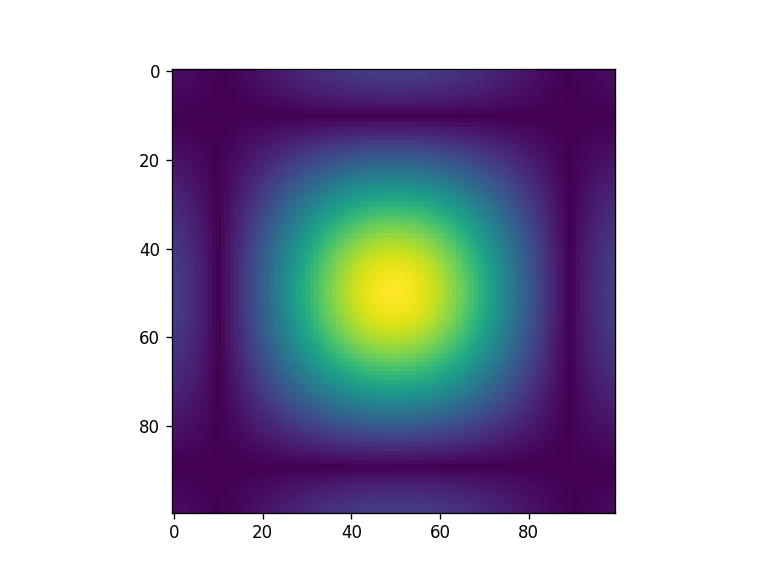

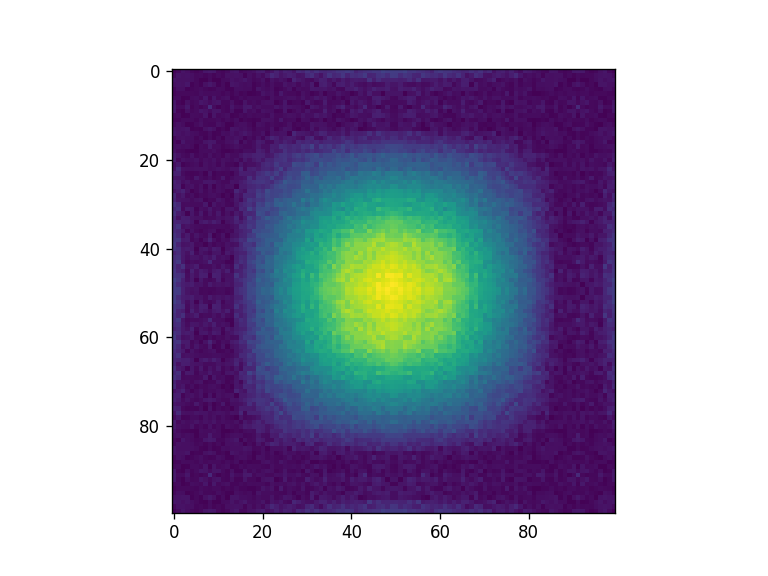

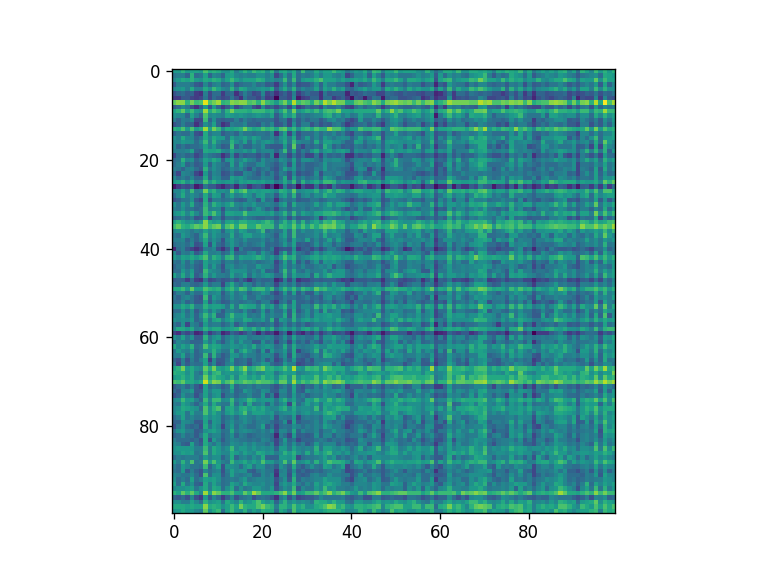

In [10]:
# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

focal_length = 0.2

x = np.linspace(xmin*100, xmax*100, x_pixel)
y = np.linspace(ymin*100, ymax*100, y_pixel)
z = np.array([focal_length])


screen = moe.field.Screen(x,y,z)


##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="bluestein"))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", pad_factor=4096))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", pad_factor=20))

fig = plt.figure() 
plt.imshow(np.abs(prop))

Above it is seen that even with large padding ASM gets blurry at larger distances.

And below we increase the distance and confirm both ASM and BLAS do not show a satisfactory result, unless we increase the padding - although still, it is not perfect. 

Elapsed: 0:00:00.016926
Elapsed: 0:00:14.377919
Elapsed: 0:00:53.968709


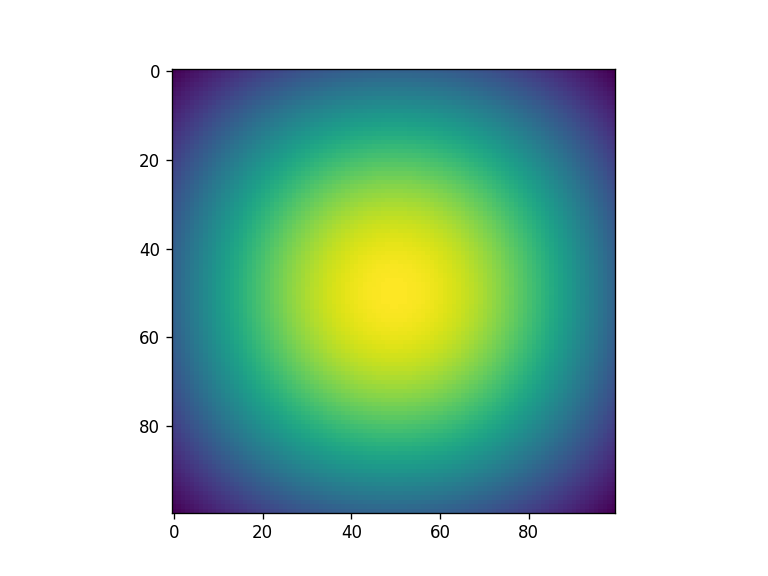

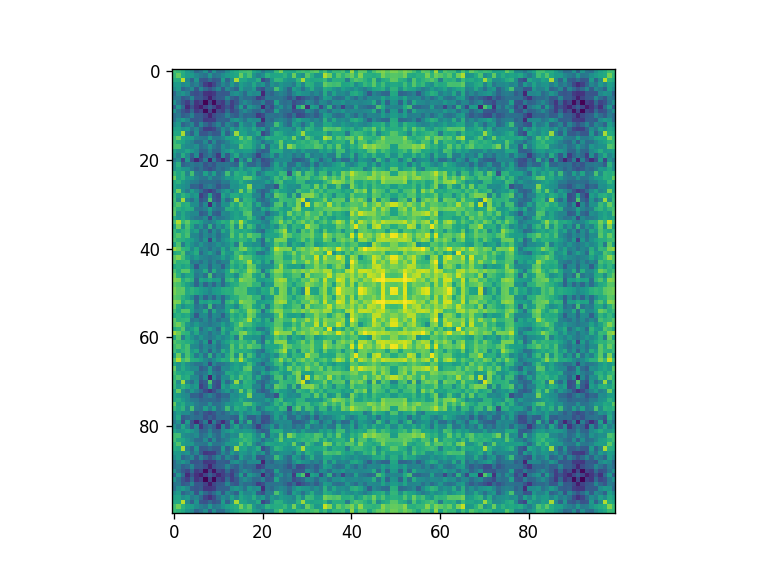

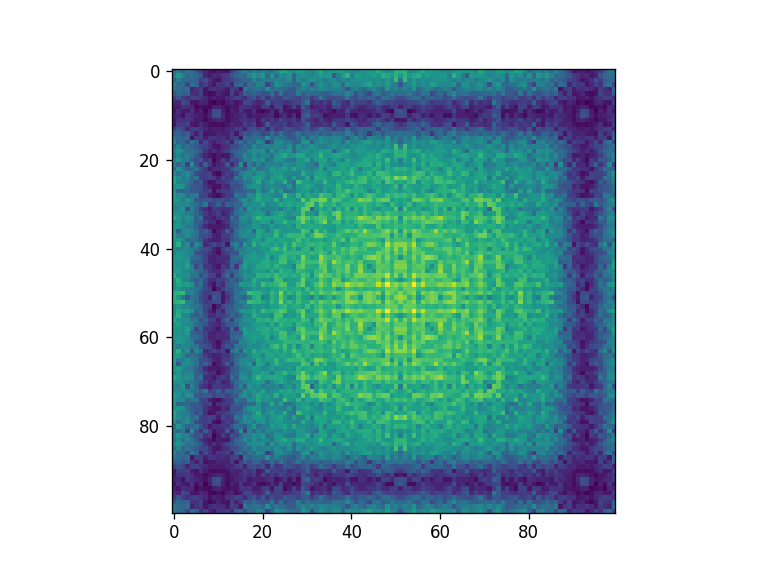

In [11]:
# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

focal_length = 0.4

x = np.linspace(xmin*100, xmax*100, x_pixel)
y = np.linspace(ymin*100, ymax*100, y_pixel)
z = np.array([focal_length])


screen = moe.field.Screen(x,y,z)


##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="bluestein"))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", pad_factor=4096))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", modedef = "BLAS", pad_factor=4096))

fig = plt.figure() 
plt.imshow(np.abs(prop))



Elapsed: 0:00:00.024890
Elapsed: 0:02:46.676613
Elapsed: 0:03:04.533663


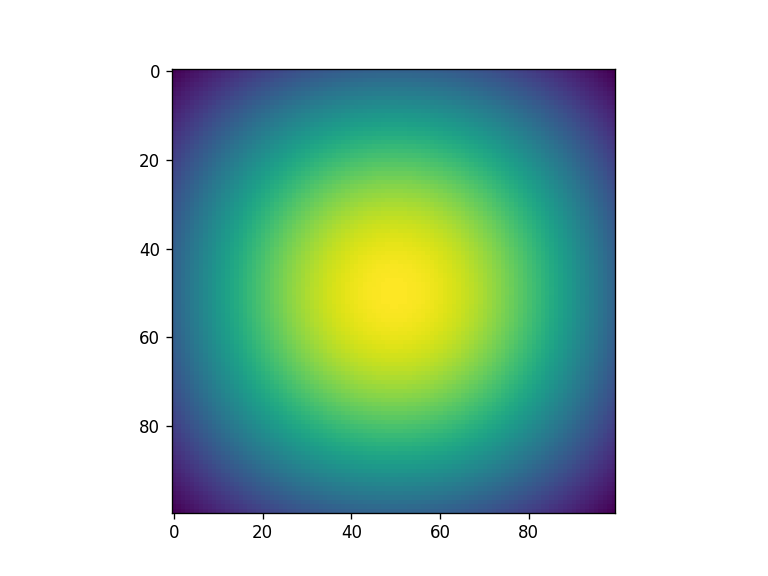

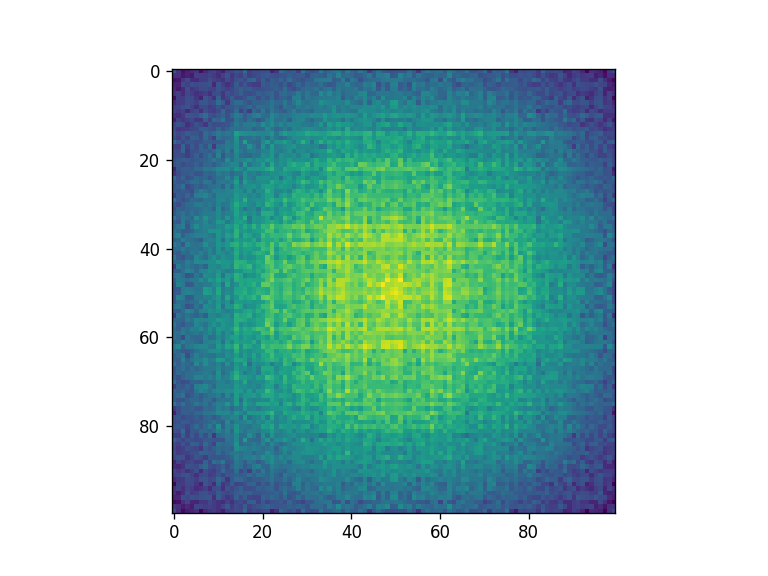

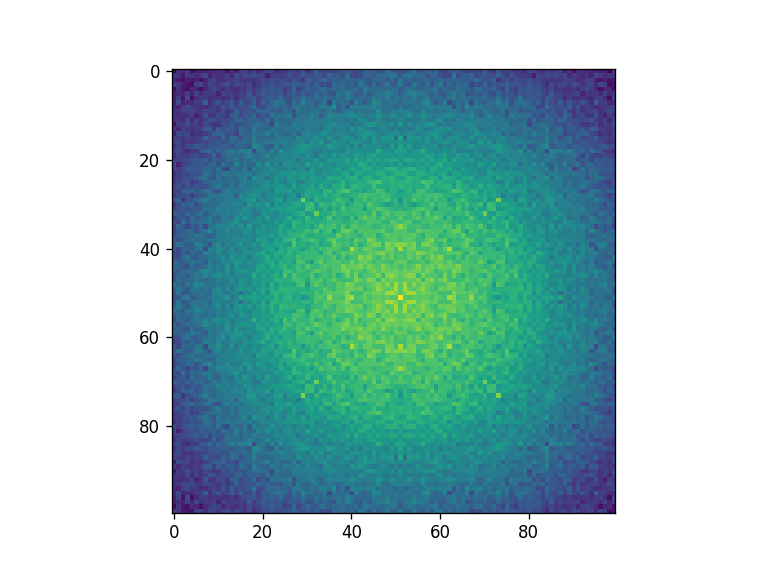

In [12]:
# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

focal_length = 0.4

x = np.linspace(xmin*100, xmax*100, x_pixel)
y = np.linspace(ymin*100, ymax*100, y_pixel)
z = np.array([focal_length])


screen = moe.field.Screen(x,y,z)


##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="bluestein"))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", modedef = "czt", pad_factor=2*4096))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", modedef = "BLAS", pad_factor=2*4096))

fig = plt.figure() 
plt.imshow(np.abs(prop))

SASM, while it seems to improve over the ASM (with czt or BLAS), seems to not be perfect as well. 

Elapsed: 0:00:00.023397
Elapsed: 0:00:00.066707


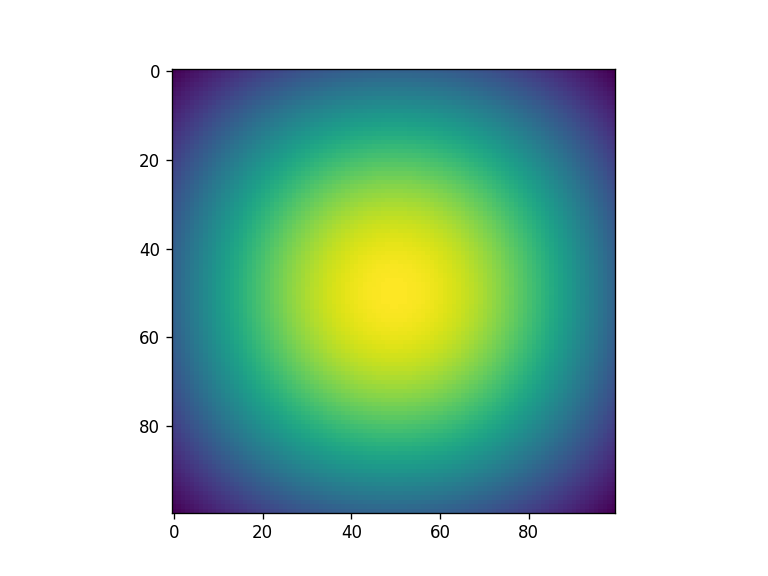

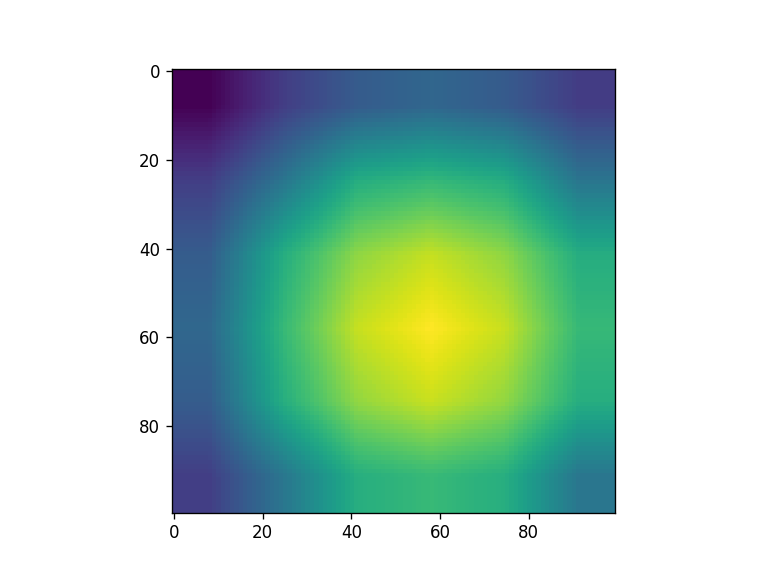

In [13]:
# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

focal_length = 0.4

x = np.linspace(xmin*100, xmax*100, x_pixel)
y = np.linspace(ymin*100, ymax*100, y_pixel)
z = np.array([focal_length])


screen = moe.field.Screen(x,y,z)


##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="bluestein"))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="SASM", pad_factor=5))

fig = plt.figure() 
plt.imshow(np.abs(prop))


In any case ASM based methods are more robust at shorter distances and less prone to padding. 

Elapsed: 0:00:00.015930
Elapsed: 0:00:01.929531
Elapsed: 0:00:00.039328


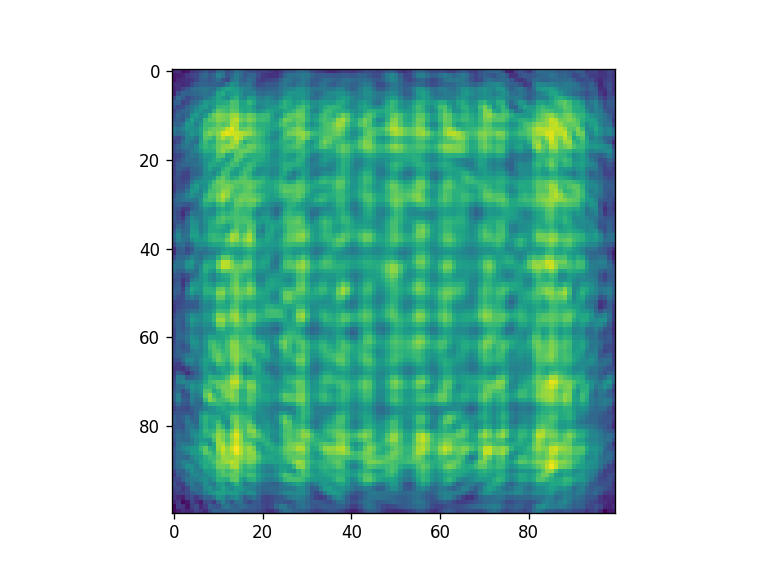

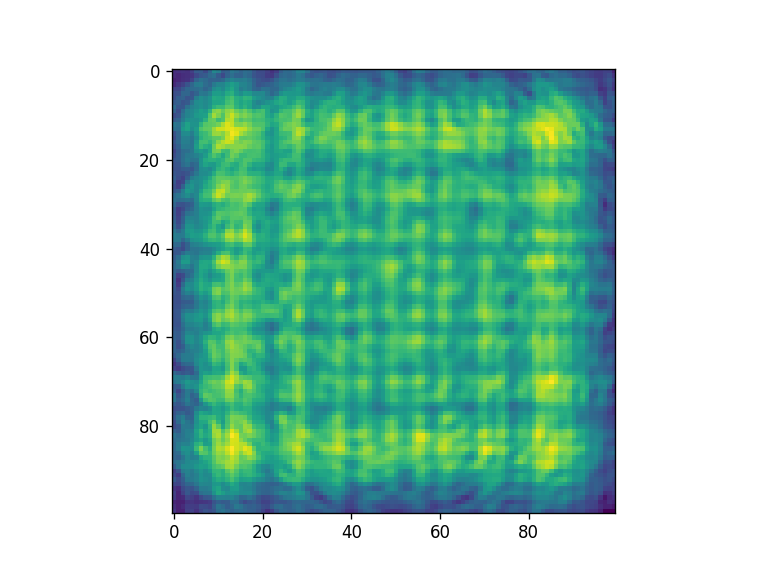

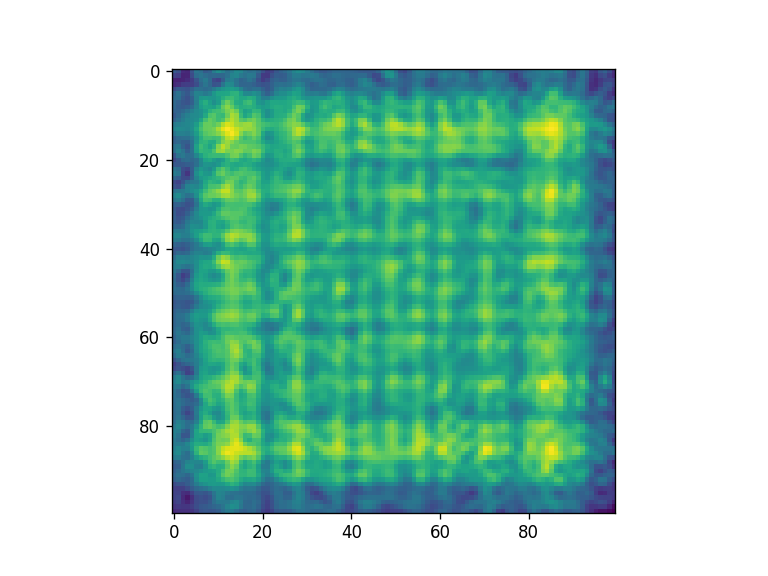

In [14]:
# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

focal_length = 0.00015

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.array([focal_length])


screen = moe.field.Screen(x,y,z)


##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="bluestein"))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", pad_factor=200))

fig = plt.figure() 
plt.imshow(np.abs(prop))

##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength, propagation_method="ASM", pad_factor=20))

fig = plt.figure() 
plt.imshow(np.abs(prop))